# Chains in LangChain

## Outline

* LLMChain
* Sequential Chains
  * SimpleSequentialChain
  * SequentialChain
* Router Chain

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
from openai import OpenAI

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

client = OpenAI()

import warnings
warnings.filterwarnings('ignore')

In [3]:
llm_model = "gpt-3.5-turbo"

In [4]:
# pip install pandas

In [5]:
import pandas as pd
df = pd.read_csv('assets/Data.csv')

In [6]:
df.head()

,Product,Review
0,Queen Size Sheet Set,I ordered a king size set. My only criticism w...
1,Waterproof Phone Pouch,"I loved the waterproof sac, although the openi..."
2,Luxury Air Mattress,This mattress had a small hole in the top of i...
3,Pillows Insert,This is the best throw pillow fillers on Amazo...
4,Milk Frother Handheld\n,I loved this product. But they only seem to l...


## LLMChain

In [7]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [8]:
llm = ChatOpenAI(temperature=0.9, model=llm_model)

In [9]:
prompt = ChatPromptTemplate.from_template("What is the best name to describe a company that makes {product}?")

In [10]:
product = "Queen Size Sheet Set"

In [11]:
text = prompt.format(product=product)
response = llm.invoke(text)
print(response.content)

Royal Dreams Bedding Co.


In [12]:
# equivalently:
chain = prompt | llm
response = chain.invoke(product)
print(response.content)

Royal Comfort Sheets


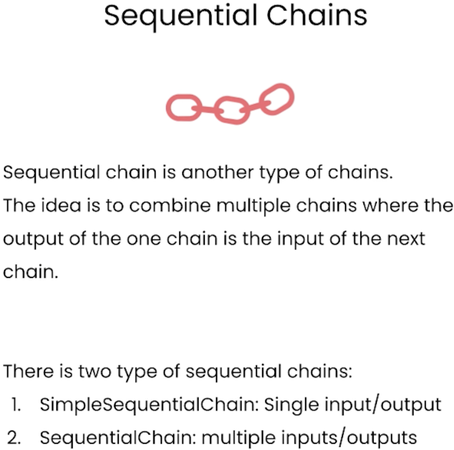

## SimpleSequentialChain

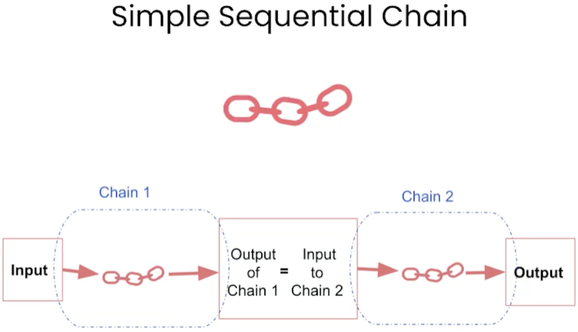

In [13]:
llm = ChatOpenAI(temperature=0.8, model=llm_model)

In [14]:
# prompt template 1
first_prompt = ChatPromptTemplate.from_template("What is the best name to describe a company that makes {product}?")

# Chain 1
chain_one = first_prompt | llm

In [15]:
# prompt template 2
second_prompt = ChatPromptTemplate.from_template("Write a 20 words description for the following company:{company_name}")

# Chain 2
chain_two = second_prompt | llm

In [16]:
from langchain_core.output_parsers import StrOutputParser

overall_simple_chain = chain_one | StrOutputParser() | chain_two

The `StrOutputParser()` is needed between the two chains because chain_one outputs an `AIMessage` object, but chain_two's prompt expects a plain `string`.
`StrOutputParser()` extracts the `.content` string from the message.

In [17]:
result = overall_simple_chain.invoke(product)
print(result.content)

Regal Linens offers luxurious and high-quality linens for the home, providing comfort and elegance to every room. Upgrade your space.


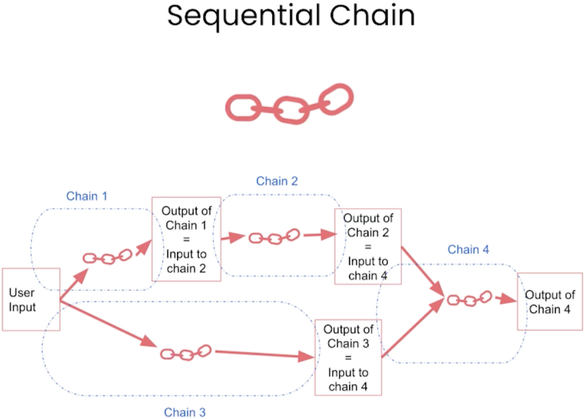

## SequentialChain

In [18]:
llm = ChatOpenAI(temperature=0.9, model=llm_model)

# prompt template 1: translate to english
first_prompt = ChatPromptTemplate.from_template("Translate the following review to english:\n\n{Review}")

# chain 1
chain_one = first_prompt | llm | StrOutputParser()

In [19]:
second_prompt = ChatPromptTemplate.from_template("Can you summarize the following review in 1 sentence: \n\n{English_Review}")

# chain 2
chain_two = second_prompt | llm | StrOutputParser()

In [20]:
# prompt template 3: detect language
third_prompt = ChatPromptTemplate.from_template("What language is the following review:\n\n{Review}")

# chain 3
chain_three = third_prompt | llm | StrOutputParser()

In [21]:
# prompt template 4: follow up message
fourth_prompt = ChatPromptTemplate.from_template(
    "Write a follow up response to the following "
    "summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}"
)

# chain 4
chain_four = fourth_prompt | llm | StrOutputParser()

In [22]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

overall_chain = (
    RunnablePassthrough.assign(English_Review=chain_one) 
    | RunnableParallel(
        English_Review=lambda x: x["English_Review"],
        summary=lambda x: chain_two.invoke({"English_Review": x["English_Review"]}),
        language=lambda x: chain_three.invoke({"Review": x["Review"]})
    )
    | RunnablePassthrough.assign(
        followup_message=lambda x: chain_four.invoke({
            "summary": x["summary"],
            "language": x["language"]
        })
    )
)

**Step 1:** `RunnablePassthrough.assign(English_Review=chain_one)`
  
You start with:
`{"Review": "Je suis fatigué"}`

`chain_one` translates it to English. `.assign()` adds the result as a new key without removing the original:

`{"Review": "Je suis fatigué", "English_Review": "I am tired"}`

---
**Step 2:** `RunnableParallel(...)`
  
Takes the dict from step 1 and runs 3 things simultaneously:

- `English_Review=lambda x: x["English_Review"]` — just copies "I am tired" (keeps it in output)
- `summary=lambda x: chain_two.invoke(...)` — summarizes "I am tired" → "The reviewer is tired"
- `language=lambda x: chain_three.invoke(...)` — detects language of original → "French"

All three run at the same time. Result:
```json
{
    "English_Review": "I am tired",
    "summary": "The reviewer is tired",
    "language": "French"
}
```

---
**Step 3:** `RunnablePassthrough.assign(followup_message=...)`
  
Takes the dict from step 2. Runs chain_four with summary="The reviewer is tired" and language="French". Adds the result as a new key:
```json
{
    "English_Review": "I am tired",
    "summary": "The reviewer is tired",
    "language": "French",
    "followup_message": "Nous sommes désolés que vous soyez fatigué..."
}
```

In [23]:
overall_chain.invoke({"Review": "Je suis fatigué"})

{'English_Review': 'I am tired',
 'summary': 'The reviewer is tired.',
 'language': 'French',
 'followup_message': "Réponse:\n\nJe suis désolé d'apprendre que le critique est fatigué. Peut-être qu'il pourrait prendre un peu de repos et se reposer un peu. Il est important de prendre soin de soi et de refaire le plein d'énergie. J'espère qu'il pourra se reposer et se sentir mieux bientôt."}

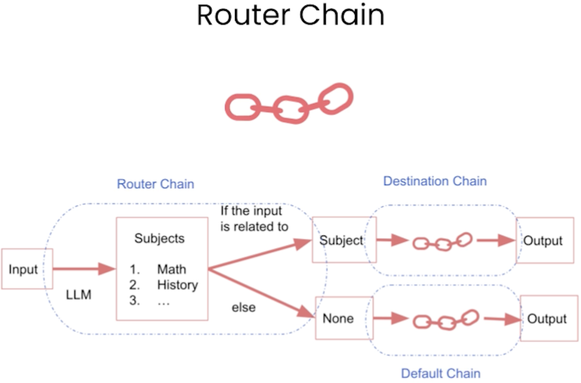

## Router Chain

**Pattern: Strategy + Registry**

The Router Chain is an implementation of the **Strategy design pattern**:
- Each specialist (physics, math, …) is a *strategy* — a chain with the same interface but different behaviour.
- A central *router* (another LLM call) decides **at runtime** which strategy to dispatch to.
- The strategies are stored in a **registry** (`destination_chains` dict), keyed by name.

```
 User input
     │
     ▼
 router_chain  ─── LLM picks the best expert ──►  {destination, next_inputs}
     │
     ▼
 destination_chains[destination]  (or default_chain)
     │
     ▼
  Answer
```

### Step 1 — Define the specialist prompts

Each expert has a system persona and expects one variable: `{input}`.

In [24]:
physics_template = """You are a very smart physics professor.
You are great at answering questions about physics in a concise and easy to understand manner.
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{input}"""

math_template = """You are a very good mathematician.
You are great at answering math questions.
You are so good because you are able to break down hard problems into their component parts,
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{input}"""

history_template = """You are a very good historian.
You have an excellent knowledge of and understanding of people,
events and contexts from a range of historical periods.
You have the ability to think, reflect, debate, discuss and evaluate the past.

Here is a question:
{input}"""

computerscience_template = """You are a successful computer scientist.
You have a passion for creativity, collaboration, forward-thinking, and strong problem-solving capabilities.
You are great at answering coding questions by describing solutions in clear, imperative steps.

Here is a question:
{input}"""

### Step 2 — Build the strategy registry

Each entry pairs a **name** and **description** with its specialist chain.
The registry (`destination_chains`) maps `name → chain`, so dispatch is a simple dict lookup later.

In [25]:
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# TypedDict makes the shape of each registry entry explicit and self-documenting
class PromptInfo(TypedDict):
    name: str
    description: str
    prompt_template: str

prompt_infos: list[PromptInfo] = [
    {"name": "physics",          "description": "Good for answering questions about physics",    "prompt_template": physics_template},
    {"name": "math",             "description": "Good for answering math questions",             "prompt_template": math_template},
    {"name": "history",          "description": "Good for answering history questions",          "prompt_template": history_template},
    {"name": "computer science", "description": "Good for answering computer science questions", "prompt_template": computerscience_template},
]

llm = ChatOpenAI(temperature=0, model=llm_model)

# Build the strategy registry: name -> specialist chain
destination_chains: dict[str, object] = {
    info["name"]: ChatPromptTemplate.from_template(info["prompt_template"]) | llm | StrOutputParser()
    for info in prompt_infos
}

# Fallback chain used when no specialist matches
default_chain = ChatPromptTemplate.from_template("{input}") | llm | StrOutputParser()

# Human-readable list of experts shown to the routing LLM
destinations_str = "\n".join(f"{info['name']}: {info['description']}" for info in prompt_infos)
print(destinations_str)

physics: Good for answering questions about physics
math: Good for answering math questions
history: Good for answering history questions
computer science: Good for answering computer science questions


### Step 3 — Build the router chain

The router is itself an LLM call. We give it:
- the list of available experts (injected into the template at build time with `.format()`)
- the user's question (injected at runtime via `invoke()`)

It returns a small JSON snippet:
```json
{
  "destination": "physics",
  "next_inputs": "What is black body radiation?"
}
```
`destination` — which expert to call (or `"DEFAULT"` when none fits)  
`next_inputs` — the (optionally reworded) question passed to that expert

In [26]:
import json, re
from typing import TypedDict
from langchain_core.prompts import PromptTemplate

# TypedDict for the structured output produced by the router LLM
class RouterOutput(TypedDict):
    destination: str   # expert name, or "DEFAULT"
    next_inputs: str   # question passed to the chosen expert

ROUTER_TEMPLATE = """Given a user question, pick the best expert to answer it.
You may rephrase the question slightly if that helps the expert.

<< AVAILABLE EXPERTS >>
{destinations}

<< FORMATTING >>
Return ONLY a markdown JSON block — no other text:
```json
{{{{
    "destination": "<expert name from the list above, or DEFAULT if none fits>",
    "next_inputs": "<original or slightly improved question>"
}}}}
```

<< USER QUESTION >>
{{input}}"""

router_prompt = PromptTemplate(
    template=ROUTER_TEMPLATE.format(destinations=destinations_str),
    input_variables=["input"],
)

router_chain = router_prompt | llm | StrOutputParser()

### Step 4 — Parse the router output

The router returns freeform text containing a JSON block. We extract it with regex.
If parsing fails for any reason (malformed JSON, unexpected format), we fall back to `DEFAULT`.

In [27]:
def parse_router_output(text: str) -> RouterOutput:
    """Extract the JSON routing decision from the LLM's markdown response."""
    match = re.search(r"```json\s*(\{.*?\})\s*```", text, re.DOTALL)
    if match:
        try:
            data = json.loads(match.group(1))
            return RouterOutput(destination=data.get("destination", "DEFAULT"),
                                next_inputs=data.get("next_inputs", text))
        except json.JSONDecodeError:
            pass
    return RouterOutput(destination="DEFAULT", next_inputs=text)

### Step 5 — The dispatch function

This is the entry point. It:
1. Asks the router LLM which expert to use
2. Parses the JSON decision
3. Looks up the expert in the registry
4. Falls back to `default_chain` if the destination is unknown or `"DEFAULT"`

In [28]:
def route(question: str, verbose: bool = False) -> str:
    """Route a question to the most appropriate specialist chain."""
    router_output = router_chain.invoke({"input": question})
    decision = parse_router_output(router_output)

    destination = decision["destination"]
    next_input  = decision["next_inputs"]

    if verbose:
        print(f"[router] destination : {destination}")
        print(f"[router] next_inputs  : {next_input}")
        print(f"[router] using chain  : {'specialist' if destination in destination_chains else 'default'}")

    specialist = destination_chains.get(destination, default_chain)
    return specialist.invoke({"input": next_input})


### Demo — route questions to the right expert

In [29]:
route("What is black body radiation?", verbose=True)

[router] destination : physics
[router] next_inputs  : Can you explain black body radiation?
[router] using chain  : specialist


"Of course! Black body radiation refers to the electromagnetic radiation emitted by a perfect absorber and emitter of radiation, known as a black body. A black body absorbs all radiation that falls on it and emits radiation at all wavelengths. The intensity and distribution of this radiation depend on the temperature of the black body.\n\nAccording to Planck's law, the intensity of black body radiation at a given wavelength is proportional to the frequency of the radiation and the temperature of the black body. As the temperature of the black body increases, the peak intensity of the radiation shifts to shorter wavelengths, resulting in a shift from red to blue light.\n\nBlack body radiation plays a crucial role in understanding the behavior of objects at high temperatures, such as stars and incandescent light bulbs. It also helped to lay the foundation for the development of quantum mechanics."

In [30]:
route("what is 2 + 2", verbose=True)

[router] destination : math
[router] next_inputs  : What is the sum of 2 and 2?
[router] using chain  : specialist


'The sum of 2 and 2 is 4.'

In [31]:
route("Why does every cell in our body contain DNA?", verbose=True)

[router] destination : biology
[router] next_inputs  : Why do all cells in the human body contain DNA?
[router] using chain  : default


"All cells in the human body contain DNA because DNA carries the genetic information that determines the characteristics and functions of an organism. DNA contains the instructions for building and maintaining the body's cells, tissues, and organs. It is essential for cell division, growth, and development. Additionally, DNA is responsible for passing on genetic information from one generation to the next. Therefore, all cells in the human body contain DNA to ensure proper functioning and continuity of life."